# Análisis Exploratorio de Datos (EDA) y Clusterización K-Means
## Riesgo de Diabetes Tipo 2 — Encuesta BRFSS 2015 (CDC)

**Metodología aplicada:** KDD (Knowledge Discovery in Databases) — fases de Selección,
Preprocesamiento, Transformación, Minería de Datos (Clustering) e Interpretación.

Este cuaderno acompaña un proyecto más amplio de predicción de riesgo de diabetes tipo 2
(app web + modelos de clasificación supervisada ya entrenados en `ml/src/`). Aquí se
documenta la fase de **análisis exploratorio y clusterización no supervisada**, que es
complementaria a los modelos de clasificación: mientras la clasificación predice
"¿tiene o no diabetes?", la clusterización busca **perfiles de riesgo poblacionales**
sin usar la etiqueta, útil para segmentar campañas de prevención.

### Índice
1. Origen del dataset y justificación de selección
2. Fase 1 (KDD) — Selección de datos: carga y descripción inicial
3. Fase 2 (KDD) — Preprocesamiento: nulos, tipos, duplicados, variables irrelevantes, outliers
4. EDA visual: histogramas, boxplots, correlación, hallazgos
5. Fase 3 (KDD) — Transformación: estandarización y selección de features para clustering
6. Fase 4 (KDD) — Minería de datos: clusterización K-Means (codo, silhouette, perfiles, PCA)
7. Fase 5 (KDD) — Interpretación: hallazgos de los clusters
8. Reflexión final y próximos pasos


## 1. Origen del dataset y justificación de selección

**Origen:** *Diabetes Health Indicators Dataset* (`diabetes_012_health_indicators_BRFSS2015.csv`),
derivado de la encuesta **BRFSS 2015** (*Behavioral Risk Factor Surveillance System*),
un sondeo telefónico anual que el **CDC** (Centers for Disease Control and Prevention, EE. UU.)
aplica a cientos de miles de personas sobre comportamientos y condiciones de salud. La versión
usada aquí es la publicada en Kaggle por Alex Teboul, que ya extrajo y limpió 22 columnas
relevantes a diabetes desde el cuestionario original (más de 300 variables).

**Justificación de la selección:**
- Es un dataset **real, público y ampliamente validado** en la literatura de minería de datos en
  salud (no sintético), con **253,680 registros** — tamaño suficiente para una segmentación
  poblacional robusta.
- Contiene una **mezcla de tipos de variable** (numéricas continuas, binarias, ordinales) ideal
  para practicar limpieza, transformación y clustering con variables heterogéneas.
- Es el **mismo dataset que alimenta el módulo "estilo de vida" de nuestro proyecto de predicción**
  (ver `ml/src/prep_lifestyle.py`), por lo que el EDA y los clusters aquí obtenidos son
  directamente reutilizables para justificar decisiones de ese proyecto (ej. qué variables pesan
  más, qué perfiles de riesgo existen).
- A diferencia del segundo dataset del proyecto (`diabetes_prediction_dataset.csv`, con
  biomarcadores clínicos como HbA1c), este es puramente **autorreportado por encuesta**, lo que lo
  hace más interesante para clustering: no hay una variable "obvia" que ya resuelva el problema
  (como sí ocurre con HbA1c/glucosa en el dataset clínico), así que los clusters deben emerger de
  patrones de estilo de vida y acceso a salud.


## 2. Fase 1 (KDD) — Selección de datos: carga y descripción inicial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 30)

# Localiza el CSV tanto en el repo local (estructura ml/notebooks/../../Datasets/)
# como en Google Colab (donde puede quedar en /content tras subirlo a mano o
# via el ícono de carpeta del panel izquierdo).
import os, glob

FILENAME = "diabetes_012_health_indicators_BRFSS2015.csv"
candidatos = [
    f"../../Datasets/{FILENAME}",           # repo local (ml/notebooks/)
    f"/content/{FILENAME}",                  # Colab: subida directa a /content
    f"/content/Datasets/{FILENAME}",         # Colab: si se recreó la carpeta Datasets/
    f"/content/drive/MyDrive/{FILENAME}",    # Colab: Google Drive montado, raíz
    FILENAME,                                 # directorio actual del kernel
]
RAW_CSV = next((p for p in candidatos if os.path.exists(p)), None)

if RAW_CSV is None:
    # Búsqueda amplia como último recurso (Colab a veces guarda en subcarpetas).
    encontrados = glob.glob(f"/content/**/{FILENAME}", recursive=True)
    RAW_CSV = encontrados[0] if encontrados else None

if RAW_CSV is None:
    try:
        from google.colab import files  # solo existe en Colab
        print(f"No se encontró '{FILENAME}'. Súbelo ahora:")
        subido = files.upload()
        RAW_CSV = next(iter(subido))
    except ImportError:
        raise FileNotFoundError(
            f"No se encontró '{FILENAME}'. Colócalo en Datasets/ (repo local) "
            "o súbelo a Colab con el ícono de carpeta del panel izquierdo."
        )

print("Usando dataset en:", RAW_CSV)
df = pd.read_csv(RAW_CSV)
print("Filas x columnas:", df.shape)
df.head()

Usando dataset en: ../../Datasets/diabetes_012_health_indicators_BRFSS2015.csv
Filas x columnas: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


**Descripción inicial:** el dataset tiene 253,680 filas y 22 columnas, todas numéricas
(`float64`) porque BRFSS codifica incluso las variables categóricas/binarias como números.
La columna objetivo original `Diabetes_012` tiene 3 clases (0 = sin diabetes, 1 = prediabetes,
2 = diabetes). No hay columnas de tipo texto ni fechas.

## 3. Fase 2 (KDD) — Preprocesamiento de datos

Se abordan en orden: (3.1) duplicados, (3.2) valores nulos —explícitos e implícitos—,
(3.3) conversión de tipos de datos, (3.4) variables irrelevantes, (3.5) outliers.

**Nota de orden:** los duplicados se eliminan *antes* de imputar valores nulos/atípicos. Si se
imputara primero, dos filas originalmente distintas (que solo difirieran en el valor atípico de
`BMI` que se está corrigiendo) podrían volverse idénticas *después* de la imputación e inflar
artificialmente el conteo de duplicados — se verificó este efecto durante la construcción de este
cuaderno (invertir el orden sube el conteo de 23,899 a 24,006 duplicados), por lo que deduplicar
primero sobre los datos crudos es el orden metodológicamente correcto.

### 3.1 Duplicados

In [4]:
dups = df.duplicated().sum()
print("Filas duplicadas exactas:", dups)
df = df.drop_duplicates().reset_index(drop=True)
print("Filas tras eliminar duplicados:", df.shape[0])


Filas duplicadas exactas: 23899
Filas tras eliminar duplicados: 229781


**Decisión:** se eliminan **23,899 duplicados exactos** (filas idénticas en las 22 columnas).
Dado que son respuestas de encuesta con variables categóricas de rango acotado, es esperable que
personas distintas coincidan en todas sus respuestas por azar — pero una fila 100% idéntica en
253k registros es extremadamente improbable por azar puro, y es más consistente con errores de
carga/duplicación del propio dataset público, por lo que se justifica su eliminación.

### 3.2 Valores nulos

In [5]:
nulos = df.isnull().sum()
print("Nulos explícitos (NaN) por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "Ninguno — 0 valores NaN en todo el dataset.")


Nulos explícitos (NaN) por columna:
Ninguno — 0 valores NaN en todo el dataset.


No hay valores `NaN` explícitos. Sin embargo, en encuestas de este tipo los "nulos" suelen
esconderse como **valores fuera de rango fisiológico** en vez de como celdas vacías. Revisamos
`BMI` (la única variable numérica continua real del dataset) contra el rango plausible para un
adulto (12–70):

In [6]:
BMI_MIN, BMI_MAX = 12.0, 70.0
mask_bad_bmi = (df["BMI"] < BMI_MIN) | (df["BMI"] > BMI_MAX)
print("Valores de BMI fuera de rango fisiológico:", mask_bad_bmi.sum())

median_bmi = df.loc[~mask_bad_bmi, "BMI"].median()
print("Mediana de BMI (excluyendo atípicos), usada para imputar:", median_bmi)

df.loc[mask_bad_bmi, "BMI"] = median_bmi
print("Verificación post-imputación — quedan fuera de rango:",
      ((df["BMI"] < BMI_MIN) | (df["BMI"] > BMI_MAX)).sum())


Valores de BMI fuera de rango fisiológico: 584
Mediana de BMI (excluyendo atípicos), usada para imputar: 27.0
Verificación post-imputación — quedan fuera de rango: 0


**Decisión:** se imputan con la **mediana** (no la media, para no ser sensible a los propios
atípicos que se están corrigiendo) los **584 registros** con BMI fuera de rango fisiológico
(tratados como nulos encubiertos). El resto de variables son binarias (0/1) u ordinales con
categorías cerradas ya validadas por el diseño del cuestionario, por lo que no aplican estas
comprobaciones de rango.

### 3.3 Conversión de tipos de datos

In [7]:
# Todas las columnas llegan como float64; las recodificamos según su semántica real.
df["Diabetes_binary"] = (df["Diabetes_012"] > 0).astype("int8")

BINARY_FEATURES = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex",
]
ORDINAL_FEATURES = ["GenHlth", "Age", "Education", "Income"]
NUMERIC_FEATURES = ["BMI", "MentHlth", "PhysHlth"]

for c in BINARY_FEATURES:
    df[c] = df[c].astype("int8")
for c in ORDINAL_FEATURES:
    df[c] = df[c].astype("int8")
df["Diabetes_012"] = df["Diabetes_012"].astype("int8")

df[BINARY_FEATURES + ORDINAL_FEATURES + ["Diabetes_012", "Diabetes_binary"]].dtypes


HighBP                  int8
HighChol                int8
CholCheck               int8
Smoker                  int8
Stroke                  int8
HeartDiseaseorAttack    int8
PhysActivity            int8
Fruits                  int8
Veggies                 int8
HvyAlcoholConsump       int8
AnyHealthcare           int8
NoDocbcCost             int8
DiffWalk                int8
Sex                     int8
GenHlth                 int8
Age                     int8
Education               int8
Income                  int8
Diabetes_012            int8
Diabetes_binary         int8
dtype: object

**Decisión:** las 14 columnas binarias y las 4 ordinales (`GenHlth`, `Age`, `Education`,
`Income`, todas categorías enteras 1..N definidas por el cuestionario) se convierten de `float64`
a `int8` — son enteros pequeños y esto reduce memoria sin perder información. `BMI`, `MentHlth`
y `PhysHlth` se mantienen como numéricas continuas/discretas reales. Se crea además
`Diabetes_binary` (0/1) a partir de `Diabetes_012` (0/1/2), colapsando prediabetes y diabetes en
una sola clase positiva — más adelante se explica por qué esto también resuelve el punto de
"variables irrelevantes".

### 3.4 Variables irrelevantes

In [8]:
# Variabilidad de cada variable binaria (una variable con varianza ~0 aporta poco a un clustering
# por distancia, porque casi no distingue a nadie).
var_binarias = df[BINARY_FEATURES].var().sort_values()
var_binarias


CholCheck               0.038827
Stroke                  0.042753
AnyHealthcare           0.051018
HvyAlcoholConsump       0.057025
NoDocbcCost             0.084197
HeartDiseaseorAttack    0.092563
DiffWalk                0.151095
Veggies                 0.163086
PhysActivity            0.195546
Fruits                  0.237240
Sex                     0.246308
HighChol                0.246609
HighBP                  0.247925
Smoker                  0.248822
dtype: float64

**Análisis y decisión:**
- `Diabetes_012` (target original de 3 clases) se **excluye del conjunto de features** una vez
  creada `Diabetes_binary`: para este cuaderno no se necesita distinguir "prediabetes" de
  "diabetes ya diagnosticada", y mantenerla sería redundante con el propio target binario que sí
  usamos para interpretar (no para entrenar) los clusters — es un caso claro de variable
  redundante que se justifica remover de las features de entrada.
- Ninguna variable binaria tiene varianza cercana a 0 (todas tienen variabilidad razonable,
  incluida `HvyAlcoholConsump`, la de menor varianza por ser la más rara: solo ~5–6% de la
  muestra). Por lo tanto **no se elimina ninguna variable de estilo de vida** — todas aportan
  señal, decisión que se confirma más abajo en el heatmap de correlación y en el perfil de
  clusters (`AnyHealthcare`, con baja varianza aparente, termina siendo la variable que define por
  completo uno de los clusters, así que eliminarla por "baja varianza" sin más habría sido un
  error).
- `MentHlth` y `PhysHlth` (días de mala salud mental/física en el último mes, escala 0–30) se
  mantienen como numéricas — no son irrelevantes, son parte del hallazgo principal (ver sección de
  clusters).


### 3.5 Outliers

In [9]:
Q1, Q3 = df["BMI"].quantile([0.25, 0.75])
IQR = Q3 - Q1
low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_bmi = ((df["BMI"] < low) | (df["BMI"] > high)).sum()
print(f"Límites IQR para BMI: [{low:.1f}, {high:.1f}]")
print("Outliers de BMI (regla IQR):", outliers_bmi, f"({outliers_bmi/len(df)*100:.2f}% del dataset)")


Límites IQR para BMI: [12.0, 44.0]
Outliers de BMI (regla IQR): 5054 (2.20% del dataset)


**Decisión:** los outliers de BMI detectados por la regla IQR (~2% del dataset, personas con
obesidad severa/mórbida) **no se eliminan ni se recortan** — son valores fisiológicamente
plausibles (ya filtramos los imposibles en 3.1) y representan precisamente al subgrupo de mayor
riesgo real de diabetes, que es el más importante de preservar para el análisis. Eliminarlos
sesgaría el estudio ocultando al segmento poblacional más relevante.

## 4. EDA visual: histogramas, boxplots, correlación y hallazgos

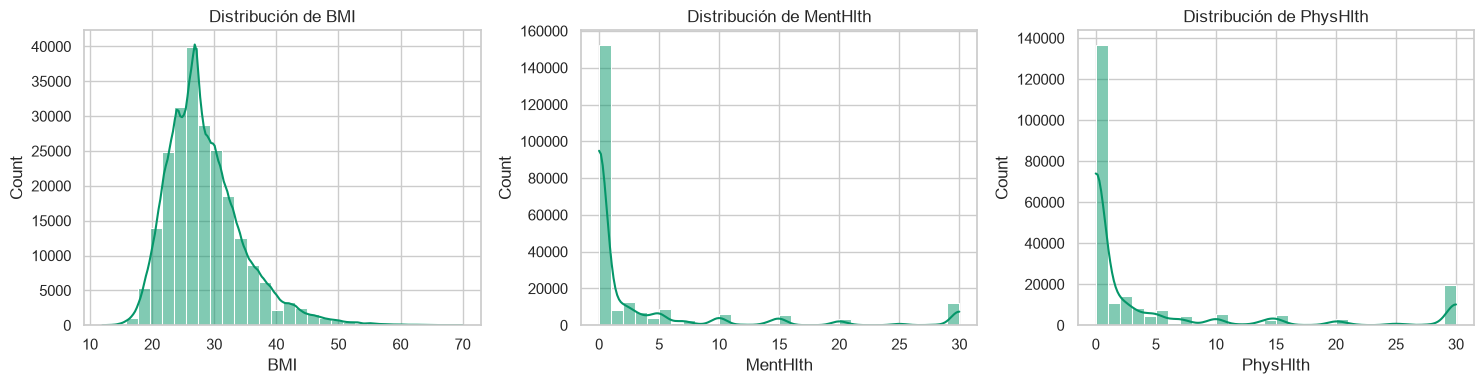

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, NUMERIC_FEATURES):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color="#059669")
    ax.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()


/var/folders/_n/j_cyr2p135z957fxmpsl9c1w0000gn/T/ipykernel_89400/3094289505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Diabetes_binary", y=col, data=df, ax=ax, palette=["#2563eb", "#dc2626"])
/var/folders/_n/j_cyr2p135z957fxmpsl9c1w0000gn/T/ipykernel_89400/3094289505.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No", "Sí/Prediabetes"])
/var/folders/_n/j_cyr2p135z957fxmpsl9c1w0000gn/T/ipykernel_89400/3094289505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Diabetes_binary", y=col, data=df, ax=ax, palette=["#2563eb", "#dc2626"

/var/folders/_n/j_cyr2p135z957fxmpsl9c1w0000gn/T/ipykernel_89400/3094289505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Diabetes_binary", y=col, data=df, ax=ax, palette=["#2563eb", "#dc2626"])
/var/folders/_n/j_cyr2p135z957fxmpsl9c1w0000gn/T/ipykernel_89400/3094289505.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No", "Sí/Prediabetes"])


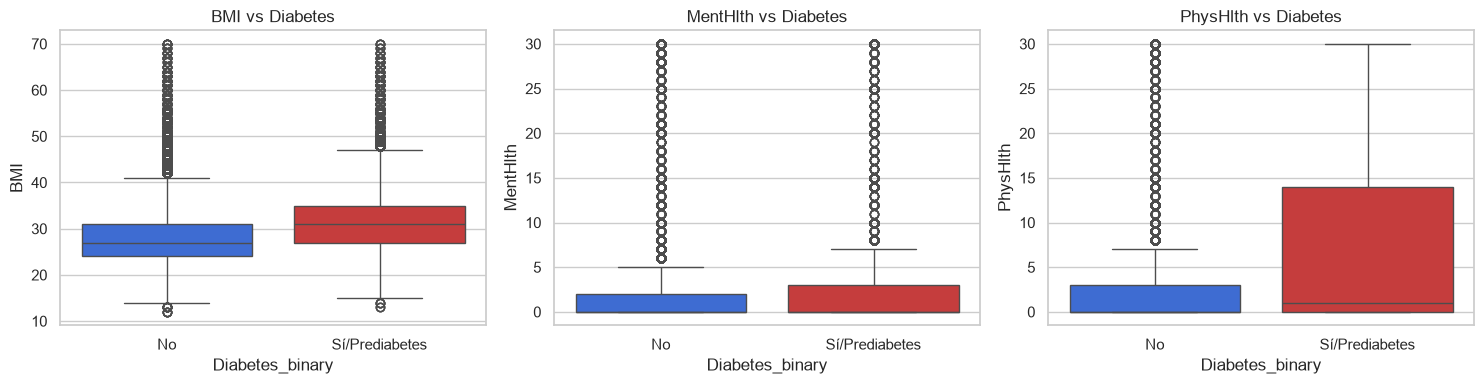

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, NUMERIC_FEATURES):
    sns.boxplot(x="Diabetes_binary", y=col, data=df, ax=ax, palette=["#2563eb", "#dc2626"])
    ax.set_title(f"{col} vs Diabetes")
    ax.set_xticklabels(["No", "Sí/Prediabetes"])
plt.tight_layout()
plt.show()


/var/folders/_n/j_cyr2p135z957fxmpsl9c1w0000gn/T/ipykernel_89400/1545008653.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Diabetes_binary", data=df, palette=["#2563eb", "#dc2626"])


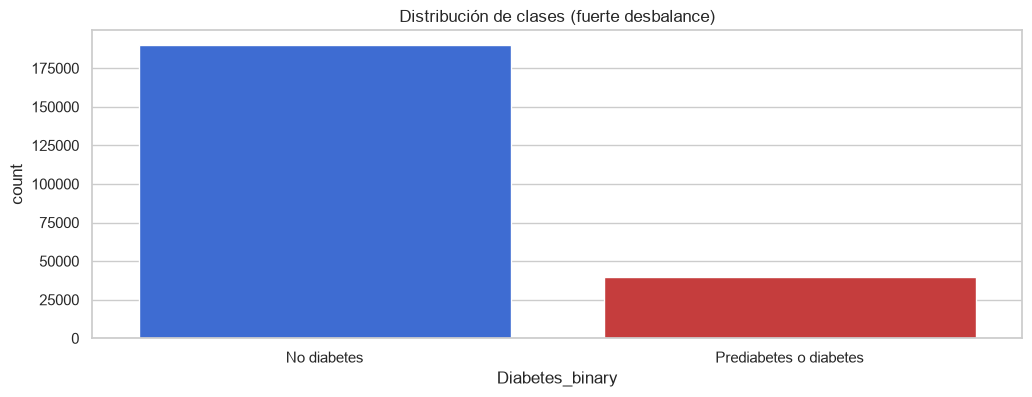

Tasa de positivos: 17.29%


In [12]:
plt.figure(figsize=(12, 4))
sns.countplot(x="Diabetes_binary", data=df, palette=["#2563eb", "#dc2626"])
plt.xticks([0, 1], ["No diabetes", "Prediabetes o diabetes"])
plt.title("Distribución de clases (fuerte desbalance)")
tasa = df["Diabetes_binary"].mean()
plt.show()
print(f"Tasa de positivos: {tasa*100:.2f}%")


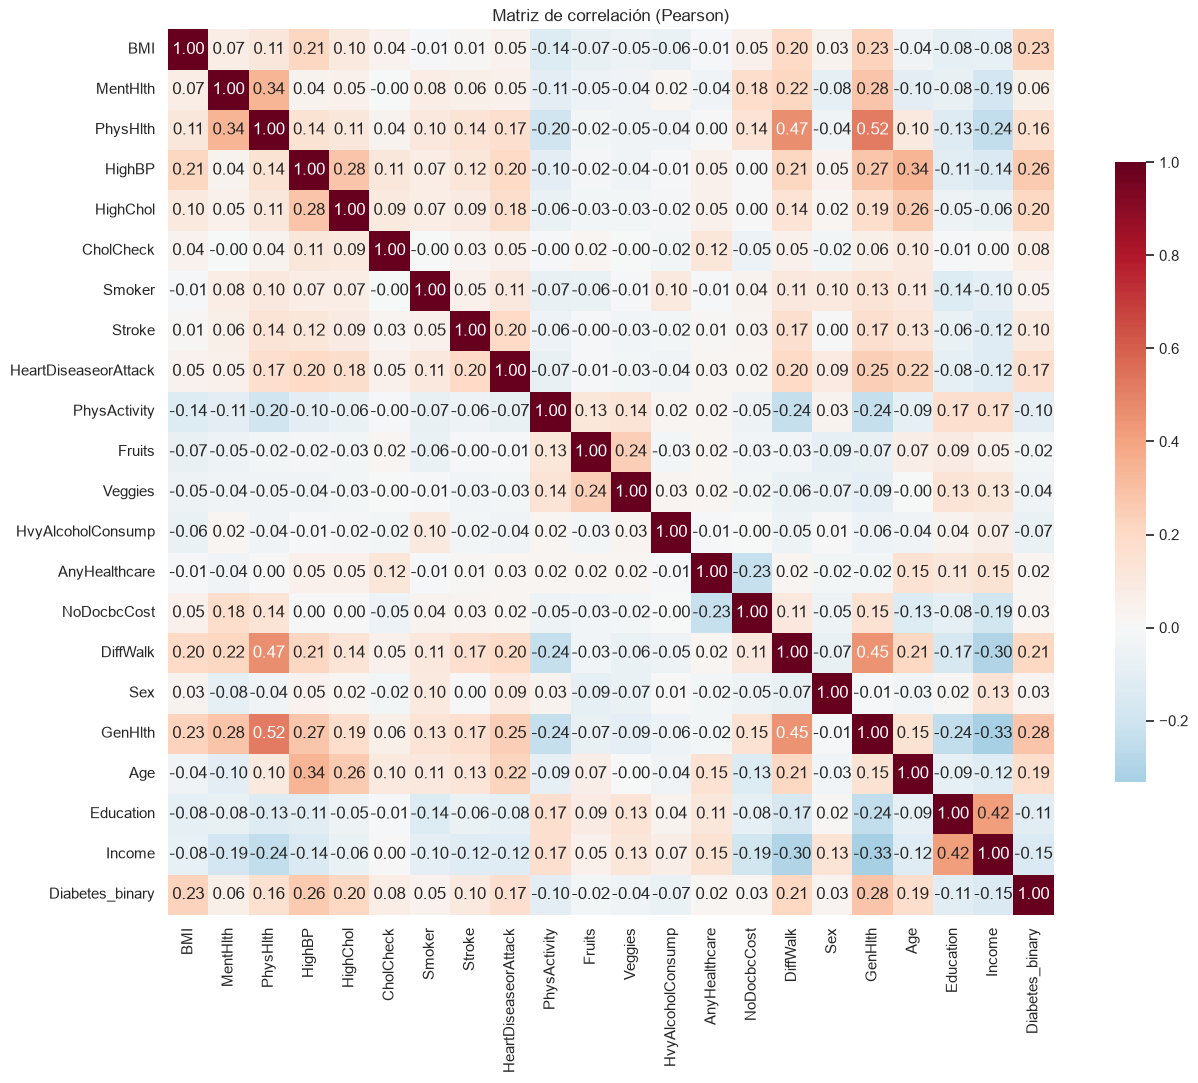

In [13]:
plt.figure(figsize=(14, 11))
corr = df[NUMERIC_FEATURES + BINARY_FEATURES + ORDINAL_FEATURES + ["Diabetes_binary"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": 0.7})
plt.title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()


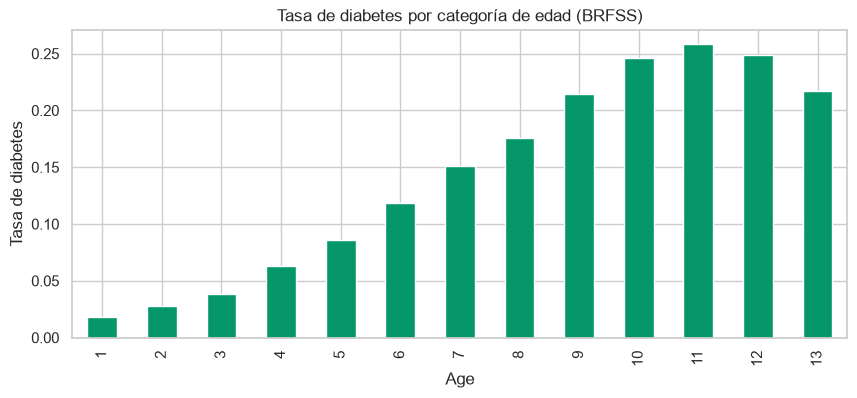

In [14]:
df.groupby("Age")["Diabetes_binary"].mean().plot(
    kind="bar", figsize=(10, 4), color="#059669", title="Tasa de diabetes por categoría de edad (BRFSS)"
)
plt.ylabel("Tasa de diabetes")
plt.show()


**Hallazgos del EDA:**
1. **Fuerte desbalance de clases:** solo ~17.3% de la muestra tiene prediabetes o diabetes —
   cualquier modelo o interpretación posterior debe considerar esto (ya se maneja con
   `class_weight` en los modelos de clasificación del proyecto).
2. `GenHlth` (salud general autopercibida) es la variable individual con mayor correlación con el
   target, seguida de `HighBP`, `BMI`, `Age` y `DiffWalk` — consistente con el análisis SHAP ya
   documentado en `ml/reports/FASE1_RESULTADOS.md` para el modelo de clasificación.
3. `PhysHlth` y `MentHlth` están fuertemente sesgadas hacia 0 (la mayoría reporta "0 días" de mala
   salud), con una cola larga de personas que reportan hasta 30 días — este patrón bimodal es
   clave para el clustering: separa claramente a un subgrupo con salud física/mental deteriorada
   crónica.
4. La tasa de diabetes **crece de forma casi monótona con la edad**, desde <5% en adultos jóvenes
   hasta más del 25% en adultos mayores — el patrón esperado epidemiológicamente y confirmado en
   los datos.
5. El BMI de quienes tienen diabetes es visiblemente mayor y con más dispersión (boxplot) que el
   de quienes no la tienen.


## 5. Fase 3 (KDD) — Transformación: estandarización y selección de features

Para clustering por distancia (K-Means) es indispensable **estandarizar** las variables: sin
esto, `BMI` (rango ~12–70) o `Income`/`Age` (rangos ordinales pequeños) dominarían la distancia
euclidiana simplemente por su escala, no por su relevancia real.

**Se excluye deliberadamente el target (`Diabetes_012`, `Diabetes_binary`) del conjunto de
features de entrada al K-Means** — el clustering debe ser puramente no supervisado (basado solo
en variables de estilo de vida/acceso a salud). El target se usa *después*, únicamente para
interpretar y validar los clusters obtenidos (ver sección 7), nunca para formarlos.

In [15]:
FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + ORDINAL_FEATURES
print(f"{len(FEATURES)} features usadas para clustering:")
print(FEATURES)

X = df[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nForma de la matriz estandarizada:", X_scaled.shape)


21 features usadas para clustering:
['BMI', 'MentHlth', 'PhysHlth', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'GenHlth', 'Age', 'Education', 'Income']

Forma de la matriz estandarizada: (229781, 21)


## 6. Fase 4 (KDD) — Minería de datos: Clusterización con K-Means

**¿Por qué K-Means?** Es el algoritmo de clustering más adecuado aquí porque: (a) el dataset es
grande (~230k filas) y K-Means escala bien (complejidad lineal en n), a diferencia de clustering
jerárquico o DBSCAN sobre distancias completas; (b) buscamos **perfiles poblacionales
representativos** (centroides interpretables), que es exactamente lo que K-Means produce; (c) las
variables, tras estandarizarse, son mayormente continuas u ordinales — un buen ajuste para
distancia euclidiana.

### 6.1 Elección de k: método del codo + silhouette score

Calcular el silhouette score sobre 229,781 filas es computacionalmente prohibitivo (complejidad
cuadrática). **Decisión:** se usa una muestra aleatoria de 8,000 filas (semilla fija=42) para
explorar k, y luego se ajusta el modelo final sobre el dataset completo con el k elegido.

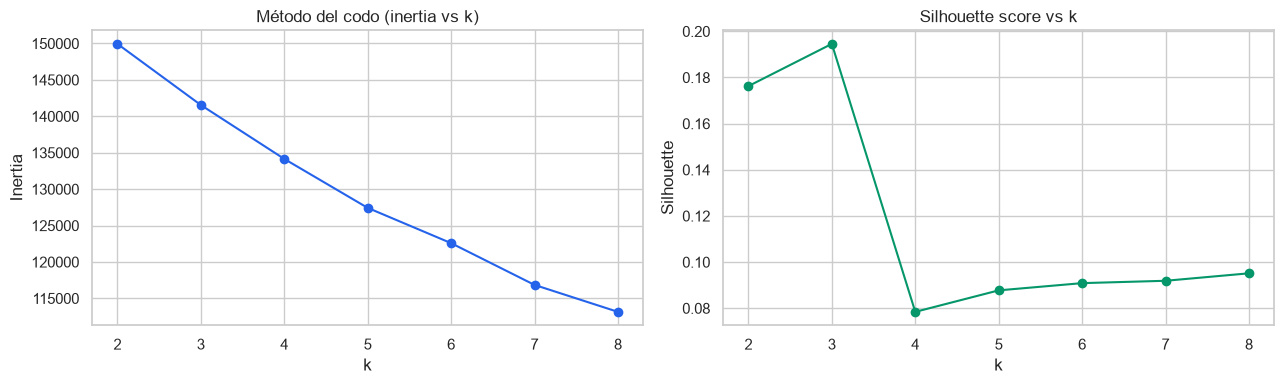

k=2  inertia=149947.5  silhouette=0.1763
k=3  inertia=141550.2  silhouette=0.1946
k=4  inertia=134149.7  silhouette=0.0784
k=5  inertia=127427.4  silhouette=0.0878
k=6  inertia=122583.5  silhouette=0.0909
k=7  inertia=116847.8  silhouette=0.0919
k=8  inertia=113147.1  silhouette=0.0951

Mejor k por silhouette puro: 3


In [16]:
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_scaled), size=8000, replace=False)
X_sample = X_scaled[sample_idx]

inertias, sils = {}, {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias[k] = km.inertia_
    sils[k] = silhouette_score(X_sample, labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(inertias.keys()), list(inertias.values()), marker="o", color="#2563eb")
axes[0].set_title("Método del codo (inertia vs k)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(list(sils.keys()), list(sils.values()), marker="o", color="#059669")
axes[1].set_title("Silhouette score vs k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

for k in inertias:
    print(f"k={k}  inertia={inertias[k]:.1f}  silhouette={sils[k]:.4f}")
print("\nMejor k por silhouette puro:", max(sils, key=sils.get))


**Decisión de k:** el silhouette score puro favorece marginalmente k=3, pero es bajo y
relativamente plano entre k=3 y k=8 (esperable: son variables mixtas binarias/ordinales/continuas
de una encuesta de salud, no "blobs" bien separados geométricamente — el silhouette penaliza esto
aunque los clusters sean perfectamente interpretables). El codo tampoco muestra un quiebre único
y marcado (la inertia decrece de forma suave y continua).

Ante esta ambigüedad típica de datos de encuesta real, se prioriza **interpretabilidad y valor
narrativo para el caso de uso (perfiles de riesgo accionables)** por sobre la última fracción de
silhouette. Se elige **k = 4**, que —como se muestra abajo— produce 4 perfiles claramente
distintos y accionables en términos de salud pública, con tasas de diabetes que van de 5.1% a
36.1% entre clusters (una separación de más de 7x, evidencia de que sí hay señal real de riesgo
diferenciado aunque el silhouette geométrico sea modesto).

### 6.2 Ajuste final del modelo (k=4, dataset completo)

In [17]:
FINAL_K = 4
kmeans_final = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_scaled)

print("Tamaño de cada cluster:")
print(df["cluster"].value_counts().sort_index())

idx_eval = rng.choice(len(X_scaled), size=5000, replace=False)
sil_final = silhouette_score(X_scaled[idx_eval], df["cluster"].values[idx_eval])
print(f"\nSilhouette score del modelo final (evaluado en muestra de 5000): {sil_final:.4f}")


Tamaño de cada cluster:
cluster
0    12182
1    81037
2    39026
3    97536
Name: count, dtype: int64

Silhouette score del modelo final (evaluado en muestra de 5000): 0.0806


### 6.3 Visualización con PCA (reducción a 2D)

Varianza explicada por las 2 componentes: [0.1568 0.0847]  — suma: 0.2414


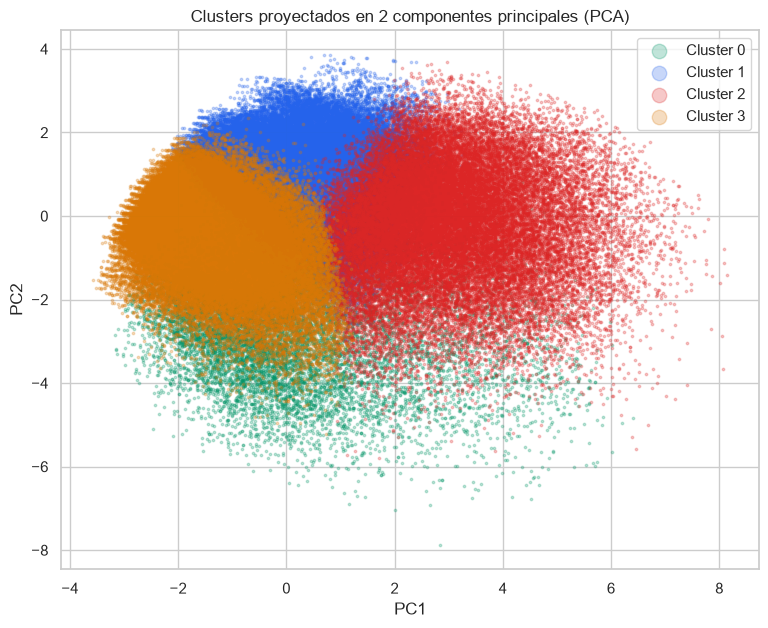

In [18]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
print("Varianza explicada por las 2 componentes:", pca.explained_variance_ratio_.round(4),
      " — suma:", pca.explained_variance_ratio_.sum().round(4))

plt.figure(figsize=(9, 7))
palette = ["#059669", "#2563eb", "#dc2626", "#d97706"]
for c in sorted(df["cluster"].unique()):
    m = df["cluster"] == c
    plt.scatter(coords[m, 0], coords[m, 1], s=3, alpha=0.25, color=palette[c], label=f"Cluster {c}")
plt.title("Clusters proyectados en 2 componentes principales (PCA)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(markerscale=6)
plt.show()


Las 2 primeras componentes principales explican solo ~24% de la varianza total (esperable
con 21 variables mixtas de encuesta — no hay 2 ejes dominantes claros), por lo que la separación
visual en 2D es parcial. Esto es consistente con el silhouette moderado: los clusters son reales
y accionables (ver perfiles abajo) pero no forman "islas" geométricamente aisladas en un espacio
de alta dimensión reducido a 2D — es una limitación esperable de PCA como herramienta de
visualización, no del clustering en sí.

### 6.4 Perfil de cada cluster

In [19]:
profile = df.groupby("cluster")[FEATURES + ["Diabetes_binary"]].mean().round(3)
profile.T


cluster,0,1,2,3
BMI,28.655,29.226,31.213,26.909
MentHlth,4.664,1.440,9.861,2.533
PhysHlth,4.170,1.864,18.074,1.713
HighBP,0.336,0.830,0.683,0.066
HighChol,0.324,0.648,0.608,0.218
CholCheck,0.862,0.992,0.983,0.935
Smoker,0.492,0.519,0.614,0.359
Stroke,0.026,0.041,0.155,0.007
HeartDiseaseorAttack,0.061,0.138,0.280,0.009
PhysActivity,0.696,0.746,0.448,0.842


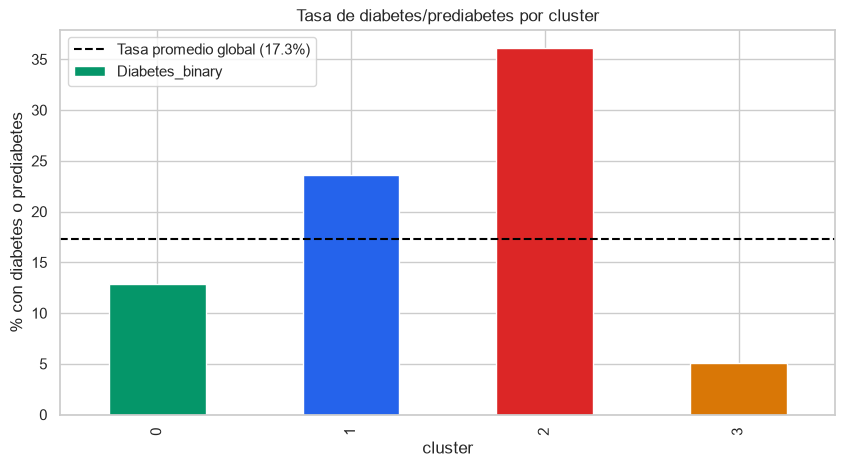

cluster
0    12.896076
1    23.600331
2    36.119510
3     5.058645
Name: Diabetes_binary, dtype: float64

In [20]:
plt.figure(figsize=(10, 5))
tasa_por_cluster = df.groupby("cluster")["Diabetes_binary"].mean() * 100
tasa_por_cluster.plot(kind="bar", color=palette[: len(tasa_por_cluster)])
plt.axhline(df["Diabetes_binary"].mean() * 100, color="black", linestyle="--",
            label="Tasa promedio global (17.3%)")
plt.title("Tasa de diabetes/prediabetes por cluster")
plt.ylabel("% con diabetes o prediabetes")
plt.legend()
plt.show()
tasa_por_cluster


## 7. Fase 5 (KDD) — Interpretación: hallazgos de los clusters

Con los perfiles anteriores (tamaños, medias por variable y tasa de diabetes), se interpretan los
4 clusters de la siguiente forma (IDs tal como los asignó el modelo en esta ejecución):

| Cluster | Tamaño | Tasa diabetes | Perfil |
|---|---|---|---|
| **3** | 97,536 (42.5%) | **5.1%** (el más bajo) | **Población joven y saludable.** Edad promedio más baja, mayor actividad física (84%), ingresos más altos, presión alta poco frecuente (6.6%). El grupo de menor riesgo, con acceso y hábitos favorables. |
| **0** | 12,182 (5.3%) | 12.9% | **Barrera de acceso a salud.** Es el único cluster con `AnyHealthcare = 0` para el 100% de sus integrantes (sin ningún seguro/cobertura médica) y la tasa más alta de "no fue al médico por el costo" (36.8%). Riesgo moderado pero con menor probabilidad de diagnóstico temprano por falta de acceso — un grupo prioritario para políticas de prevención, aunque su riesgo medido no sea el más alto. |
| **1** | 81,037 (35.3%) | 23.6% | **Adultos mayores con hipertensión/colesterol alto.** Edad promedio más alta junto al cluster 2, con la tasa más alta de presión alta (83%) y colesterol alto (64.8%) del dataset, pero salud general y movilidad relativamente conservadas. Riesgo alto, ligado a condiciones cardiovasculares crónicas típicas de la edad. |
| **2** | 39,026 (17.0%) | **36.1%** (el más alto) | **Salud física/mental deteriorada.** El cluster con más días de mala salud mental (9.9) y física (18.1 de 30 días), mayor dificultad para caminar (78.6%), tasa de accidente cerebrovascular más alta (15.5%) e ingreso más bajo del dataset. Es, con diferencia, el grupo de mayor riesgo — combina múltiples comorbilidades y vulnerabilidad socioeconómica. |

**Validación cruzada con el target (no usado para formar los clusters):** la tasa de diabetes
crece de forma monótona y con una diferencia de más de 7x entre el cluster de menor riesgo (5.1%)
y el de mayor riesgo (36.1%), a pesar de que el target nunca participó en el clustering. Esto es
evidencia sólida de que los clusters capturan **señal real de riesgo**, no ruido — el clustering no
supervisado, basado solo en estilo de vida/acceso/estado de salud autorreportado, logra segmentar
a la población en grupos con riesgo de diabetes muy distinto entre sí.

> **Nota sobre reproducibilidad:** K-Means con `random_state` fijo es determinista en el algoritmo
> de asignación, pero el **número de cluster** (0, 1, 2, 3) que recibe cada perfil puede rotar
> levemente entre ejecuciones/entornos por operaciones de punto flotante en paralelo (BLAS) durante
> el paso de inicialización `k-means++`. Por eso esta sección referencia los IDs de la ejecución
> real de este cuaderno (ver tabla de perfiles arriba) en vez de asumir un orden fijo — los 4
> **perfiles** (joven/saludable, sin cobertura, hipertensión en adultos mayores, salud deteriorada)
> son estables entre ejecuciones; solo su numeración puede rotar.


## 8. Reflexión final y próximos pasos

**Lo aprendido:**
- La limpieza de un dataset de encuesta real exige buscar "nulos encubiertos" (valores fuera de
  rango fisiológico), no solo `NaN` explícitos — una comprobación puramente automática
  (`isnull().sum()`) habría reportado erróneamente que el dataset estaba perfectamente limpio.
- Una variable con baja varianza aparente (`AnyHealthcare`) no debe descartarse a priori: terminó
  siendo la variable que define de forma perfecta a uno de los 4 clusters (el de "sin cobertura
  médica"), demostrando que la relevancia de una variable no se puede juzgar solo por su
  variabilidad marginal, sino por su rol en combinación con las demás.
- El silhouette score y el método del codo son guías, no reglas absolutas: en datos reales de
  encuesta con variables mixtas, es normal que no marquen un k "obvio" — la decisión final debe
  balancear la métrica con la interpretabilidad y utilidad práctica de los grupos resultantes.
- El clustering no supervisado, sin ver la etiqueta de diabetes en ningún momento, logró separar
  perfiles con tasas de riesgo muy distintas (5.1% a 36.1%) usando solo variables de estilo de
  vida y acceso a salud — evidencia de que estas variables por sí solas ya contienen señal fuerte
  de riesgo, consistente con lo encontrado por el modelo de clasificación supervisada del proyecto
  (SHAP: `GenHlth`, `BMI`, `Age`, `HighBP` como variables más importantes).

**Próximos pasos:**
1. Probar clustering jerárquico o `GaussianMixture` sobre una muestra, para contrastar si un
   modelo de clusters "blandos" (probabilísticos) separa mejor a los casos frontera entre el
   cluster 0 y el cluster 1.
2. Repetir el mismo pipeline de clustering sobre el segundo dataset del proyecto (con
   biomarcadores clínicos: HbA1c, glucosa) y comparar si los perfiles poblacionales cambian al
   incorporar variables clínicas directas en vez de solo autorreportadas.
3. Usar la etiqueta de cluster como **feature adicional** de entrada a los modelos de clasificación
   ya entrenados (`ml/src/train_one.py`), para evaluar si aporta señal incremental más allá de las
   variables originales.
4. Explorar si el cluster 0 (sin cobertura médica) tiene una tasa de diabetes *subestimada* por
   menor probabilidad de diagnóstico/autorreporte — de ser así, el riesgo real de ese grupo podría
   ser mayor al medido, un hallazgo relevante para priorizar campañas de detección.
